Understanding Data C-MAPSS

In [ ]:
# 1) Download C-MAPSS dataset  https://data.nasa.gov/dataset/cmapss-jet-engine-simulated-data.
#    The CMAPSS dataset has vibration, temperature, pressures, flow rate and operating conditions  of a turbofan engine.

import pandas as pd
import numpy as np

columns = ['engine_id','cycle','op_setting1','op_setting2','op_setting3'] + \
          ['sensor_' + str(i) for i in range(1,22)]

train = pd.read_csv("train_FD001.txt", sep="\s+", header=None)

train.columns = columns

train.head()

,engine_id,cycle,op_setting1,op_setting2,op_setting3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [ ]:
print('Shape fo given dataset is',train.shape)

Shape fo given dataset is (20631, 26)


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   engine_id    20631 non-null  int64  
 1   cycle        20631 non-null  int64  
 2   op_setting1  20631 non-null  float64
 3   op_setting2  20631 non-null  float64
 4   op_setting3  20631 non-null  float64
 5   sensor_1     20631 non-null  float64
 6   sensor_2     20631 non-null  float64
 7   sensor_3     20631 non-null  float64
 8   sensor_4     20631 non-null  float64
 9   sensor_5     20631 non-null  float64
 10  sensor_6     20631 non-null  float64
 11  sensor_7     20631 non-null  float64
 12  sensor_8     20631 non-null  float64
 13  sensor_9     20631 non-null  float64
 14  sensor_10    20631 non-null  float64
 15  sensor_11    20631 non-null  float64
 16  sensor_12    20631 non-null  float64
 17  sensor_13    20631 non-null  float64
 18  sensor_14    20631 non-null  float64
 19  sens

In [ ]:
train.describe()

,engine_id,cycle,op_setting1,op_setting2,op_setting3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,...,0.737553,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [ ]:
print('No. of engines is',train['engine_id'].nunique())

No. of engines is 100


In [ ]:
# 2) Understanding the data by parsing text to pandas data frames and label RUL by creating a target column.
# calculate RUL=max(cycle)−current_cycle

max_cycle = train.groupby('engine_id')['cycle'].max()
max_cycle = max_cycle.reset_index()
max_cycle.columns = ['engine_id','max_cycle']

# merge with original dataset
train = train.merge(max_cycle, on='engine_id', how='left')

In [ ]:
# add RUL column
train['RUL'] = train['max_cycle'] - train['cycle']

In [ ]:
train[['engine_id','cycle','RUL']].head(15)

,engine_id,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


In [ ]:
train.to_csv("processed_data/train_FD001_processed.csv", index=False)

In [ ]:
engine1 = train[train['engine_id'] == 1]
sensor_cols = [col for col in train.columns if 'sensor_' in col]
sensor_data = engine1[sensor_cols]

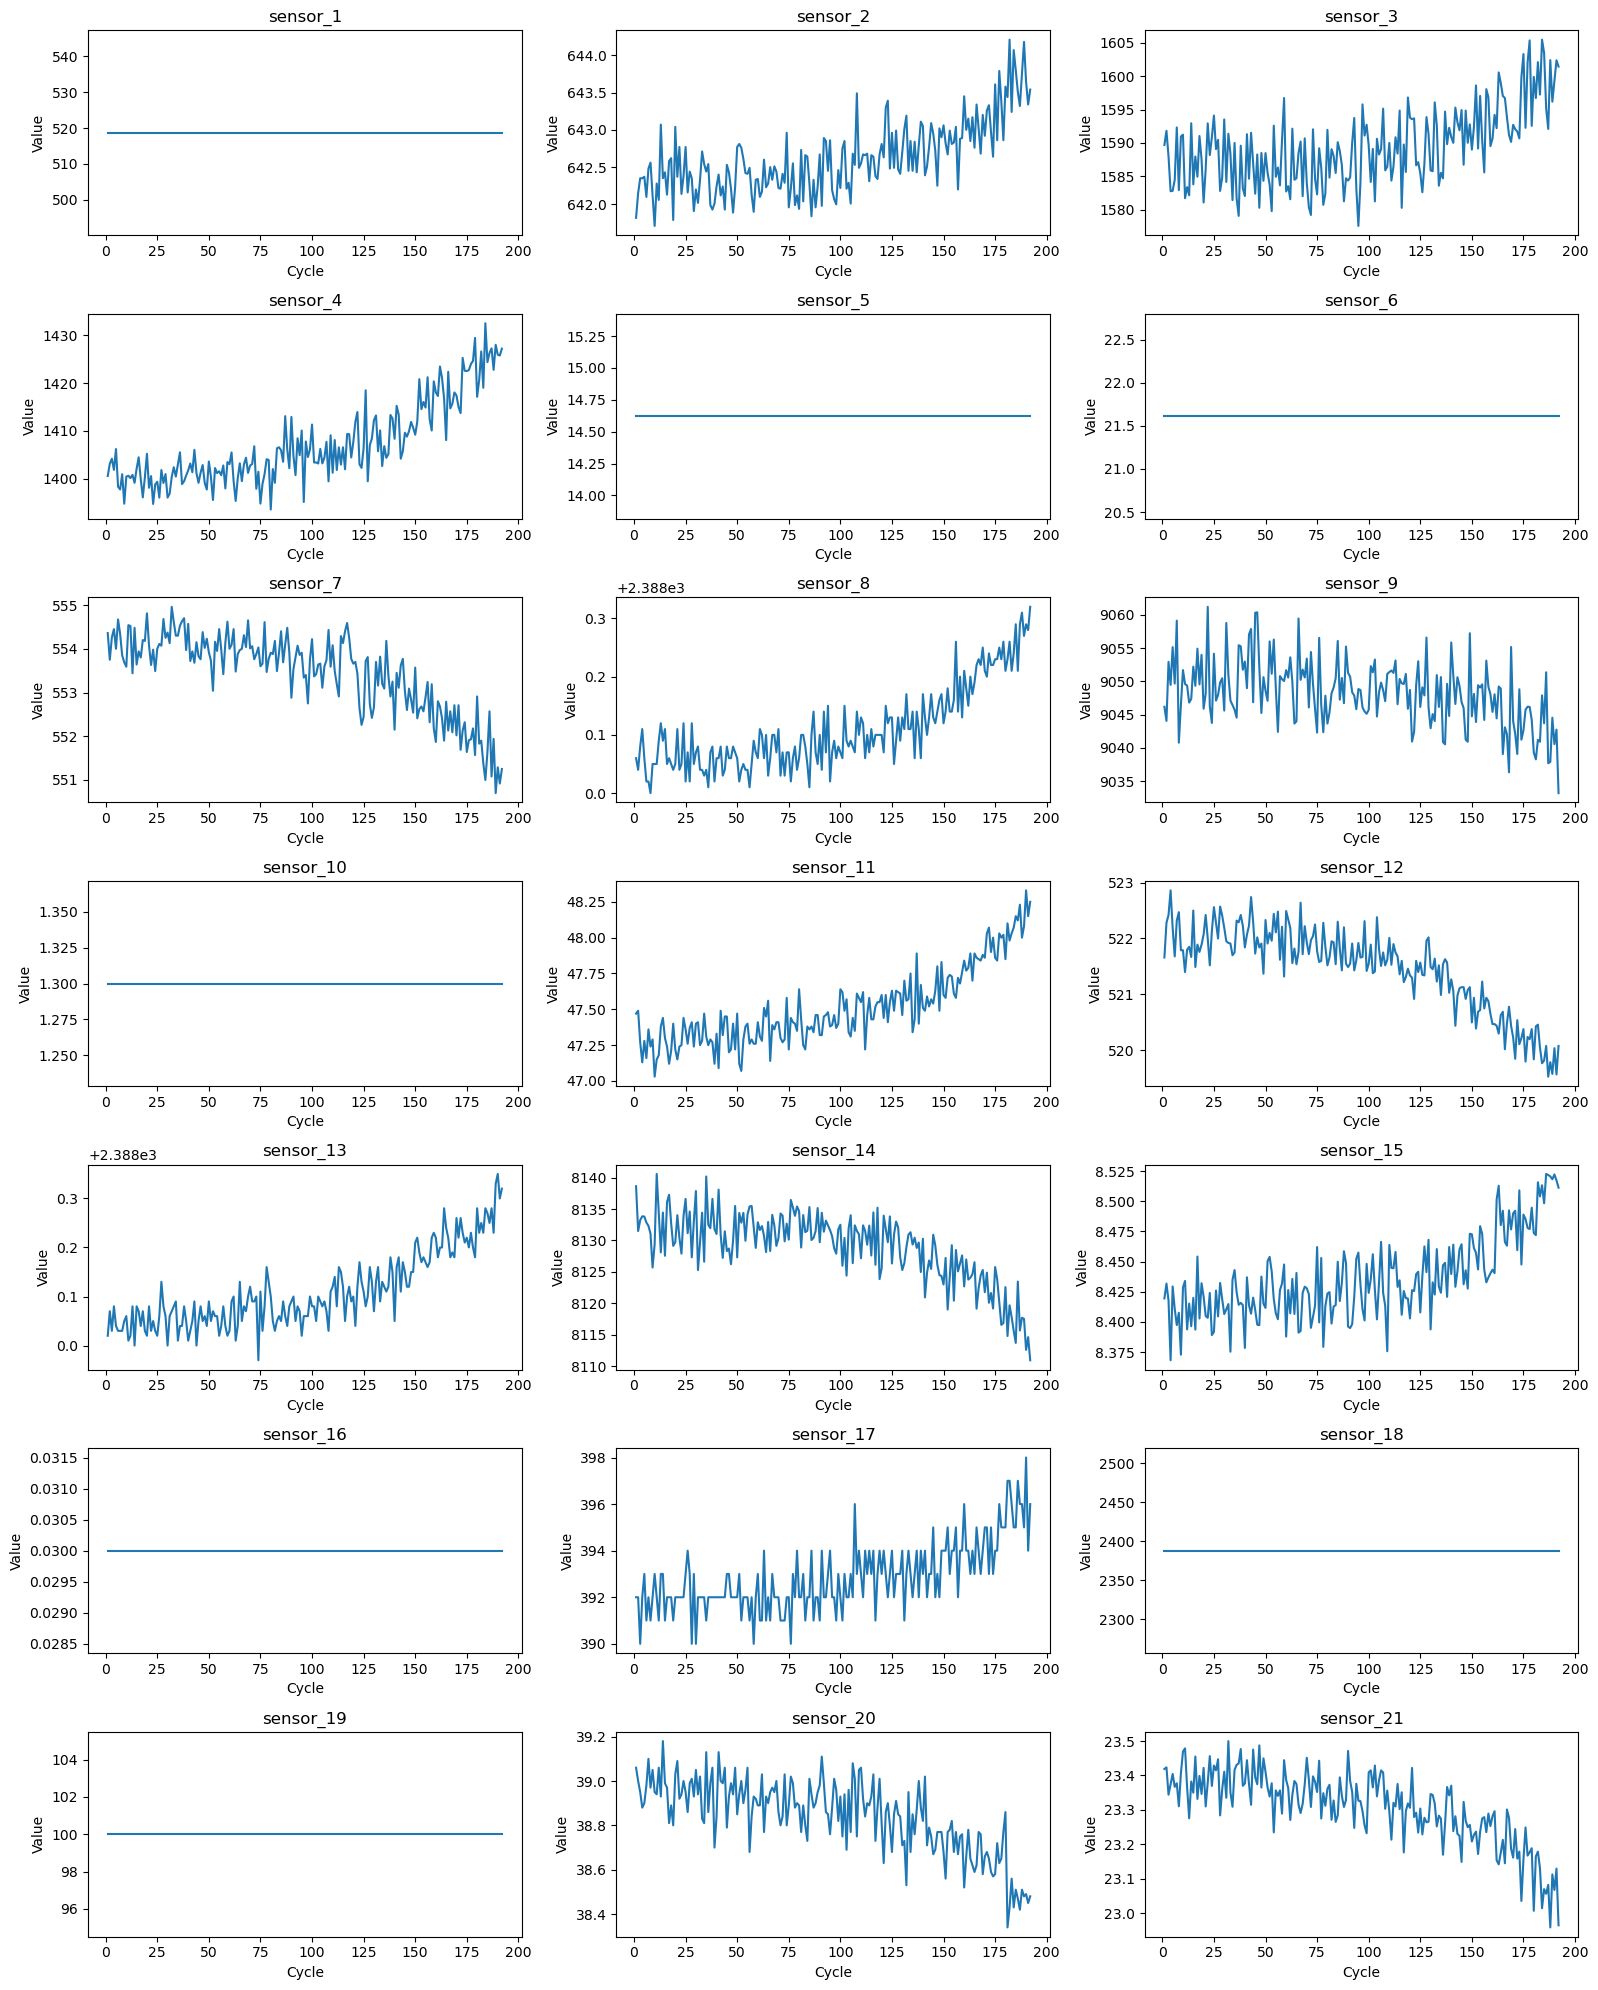

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,20))

for i, sensor in enumerate(sensor_cols):

    plt.subplot(7,3,i+1)
    plt.plot(engine1['cycle'], engine1[sensor])

    plt.title(sensor)
    plt.xlabel("Cycle")
    plt.ylabel("Value")

plt.tight_layout()
plt.show()

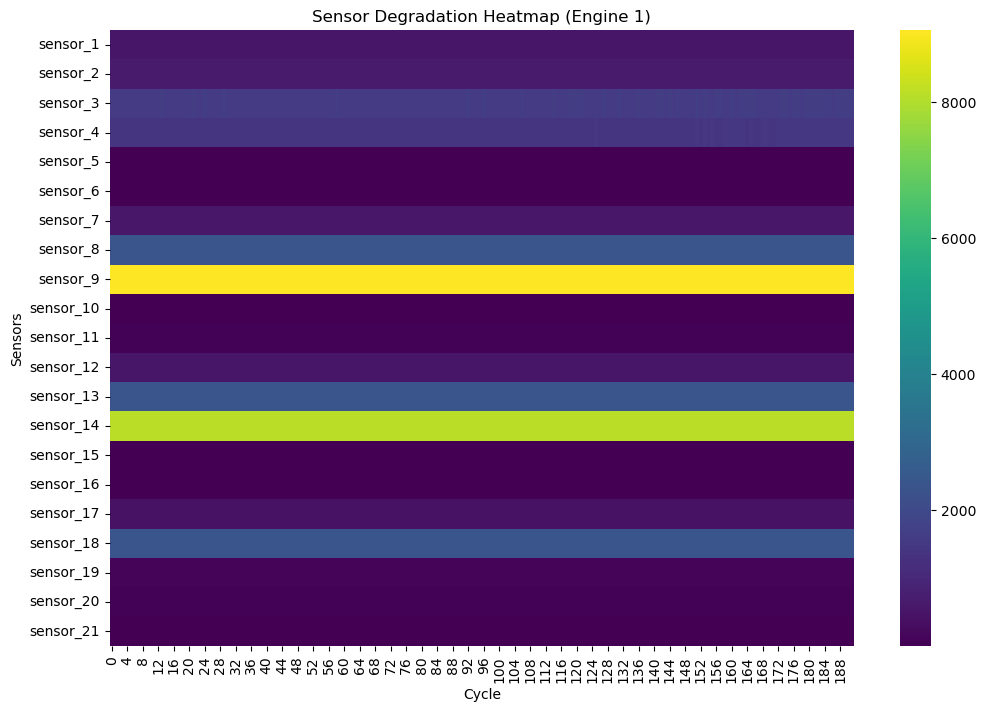

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(sensor_data.T, cmap='viridis')

plt.xlabel("Cycle")
plt.ylabel("Sensors")
plt.title("Sensor Degradation Heatmap (Engine 1)")

plt.show()

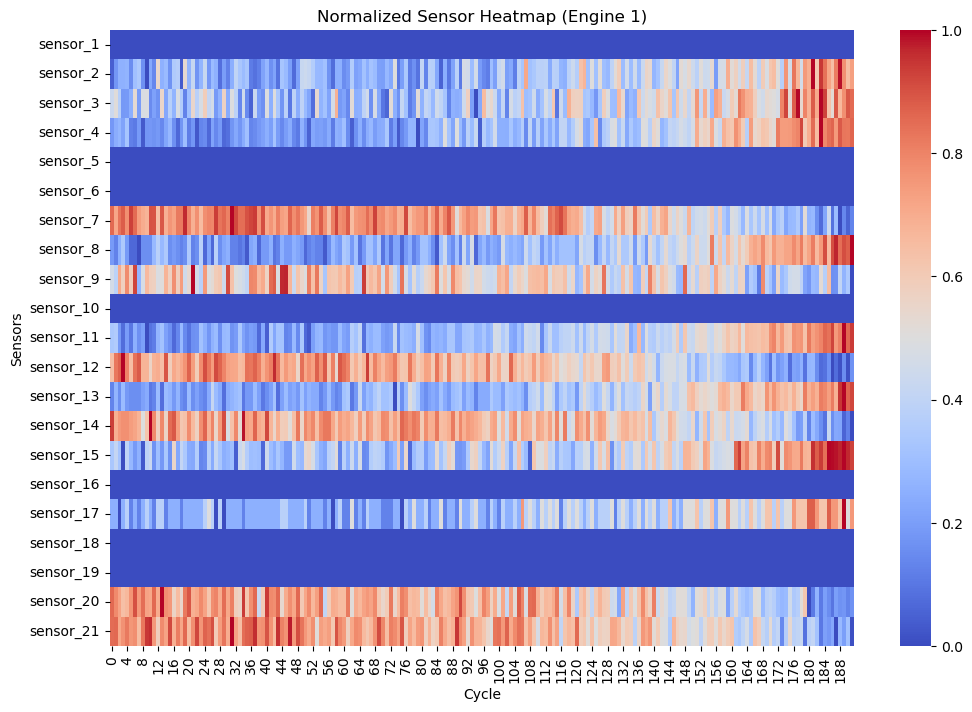

In [ ]:
# 3) Store these as csv/excel files in a folder. Visualize the degradation trends in the CMAPSS dataset. You should normalize the data using a suitable normalizer and remove non informative data columns.
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

normalized = scaler.fit_transform(sensor_data)

normalized_df = pd.DataFrame(normalized, columns=sensor_cols)

plt.figure(figsize=(12,8))
sns.heatmap(normalized_df.T, cmap='coolwarm')

plt.xlabel("Cycle")
plt.ylabel("Sensors")
plt.title("Normalized Sensor Heatmap (Engine 1)")

plt.show()

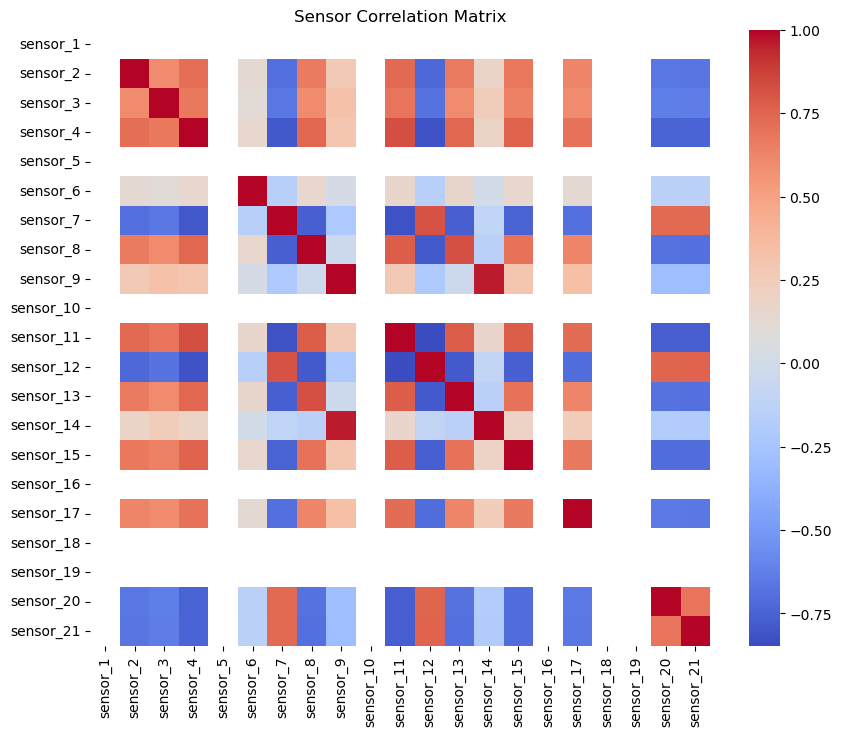

In [ ]:
corr = train[sensor_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')

plt.title("Sensor Correlation Matrix")
plt.show()

In [ ]:
sensor_cols = [col for col in train.columns if 'sensor_' in col]

sensor_variance = train[sensor_cols].var()

print(sensor_variance.sort_values())

sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    2.422479e-28
sensor_10    2.172333e-25
sensor_5     1.152399e-23
sensor_1     4.273435e-21
sensor_6     1.929279e-06
sensor_15    1.406628e-03
sensor_8     5.038938e-03
sensor_13    5.172330e-03
sensor_21    1.171825e-02
sensor_20    3.266927e-02
sensor_11    7.133568e-02
sensor_2     2.500533e-01
sensor_12    5.439850e-01
sensor_7     7.833883e-01
sensor_17    2.398667e+00
sensor_3     3.759099e+01
sensor_4     8.101089e+01
sensor_14    3.639005e+02
sensor_9     4.876536e+02
dtype: float64


In [ ]:
cols_to_remove = ['sensor_1','sensor_5','sensor_6','sensor_10','sensor_16','sensor_18','sensor_19', 'max_cycle']

train_reduced = train.drop(columns=cols_to_remove)

train_reduced.columns

Index(['engine_id', 'cycle', 'op_setting1', 'op_setting2', 'op_setting3',
       'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9',
       'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
       'sensor_17', 'sensor_20', 'sensor_21', 'RUL'],
      dtype='object')

In [ ]:
train_reduced.to_csv("processed_data/train_FD001_reduced.csv", index=False)

4) Prepare a short writeup of which columns you are removing and why.

Removal of Non-Informative Sensors.

During exploratory data analysis of the C-MAPSS dataset, sensor measurements were examined to identify features that do not contribute meaningful information for predicting engine degradation.

Variance analysis and visualization of sensor values over engine cycles revealed that several sensors remained nearly constant throughout the engine lifecycle.

The following sensors were identified as non-informative and were removed from the dataset:

            sensor_1, sensor_5, sensor_6, sensor_10, sensor_16, sensor_18, sensor_19

These sensors exhibit very low variance and minimal change over time, indicating that they do not capture degradation behavior of the engine.

Including such features in the model may introduce noise and unnecessary computational complexity without improving predictive performance.

After removing these columns, the remaining sensors contain more informative signals related to engine health, which improves the effectiveness of subsequent machine learning models for Remaining Useful Life (RUL) prediction.

In [ ]:
# 5) Generate sliding windows as time-series sequences and keep them in a separate files in separate folders.

feature_cols = [col for col in train_reduced.columns
                if col not in ['engine_id','cycle','RUL']]

def create_sliding_windows(df, window_size, feature_cols):

    X = []
    y = []

    for engine in df['engine_id'].unique():

        engine_data = df[df['engine_id'] == engine]

        data = engine_data[feature_cols].values
        rul = engine_data['RUL'].values

        for i in range(len(engine_data) - window_size):

            X.append(data[i:i+window_size])
            y.append(rul[i+window_size])

    return np.array(X), np.array(y)

window_size = 30

X_train, y_train = create_sliding_windows(train, window_size, feature_cols)

print(X_train.shape)
print(y_train.shape)

np.save("sliding_windows/train_FD001/X_train.npy", X_train)
np.save("sliding_windows/train_FD001/y_train.npy", y_train)

(17631, 30, 17)
(17631,)
